# FIFA World Cup 2026 — Data Analysis & Match Predictor

In [68]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Results

In [69]:
df = pd.read_csv('data/results.csv')
print("Shape of the DataFrame:", df.shape)
df.head()

Shape of the DataFrame: (49378, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2. Basic OPerations

In [70]:
print("Columns in the DataFrame:", df.columns)
print("Data types of each column:\n", df.dtypes)
print("Summary statistics of the DataFrame:\n", df.describe())
print("Number of unique values in each column:\n", df.nunique())
print("Number of missing values in each column:\n", df.isnull().sum())


Columns in the DataFrame: Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')
Data types of each column:
 date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object
Summary statistics of the DataFrame:
          home_score    away_score
count  49306.000000  49306.000000
mean       1.757393      1.182209
std        1.774934      1.402759
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     21.000000
Number of unique values in each column:
 date          16463
home_team       327
away_team       321
home_score       26
away_score       22
tournament      199
city           2139
country         269
neutral           2
dtype: int64
Number of missin

In [71]:
print("Top 30 tournaments in the dataset:")
print(df['tournament'].value_counts().head(30))

Top 30 tournaments in the dataset:
tournament
Friendly                                18301
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
COSAFA Cup                        

In [72]:
df['date'] = pd.to_datetime(df['date'])
print("Oldest match date:", df['date'].min())
print("Most recent match date:", df['date'].max())
print("Unique teams in the dataset:", df['home_team'].nunique() + df['away_team'].nunique())

Oldest match date: 1872-11-30 00:00:00
Most recent match date: 2026-06-27 00:00:00
Unique teams in the dataset: 648


##  3. Get only the competitive matches since 2018

In [73]:
competitive_tournaments = [
    'FIFA World Cup',
    'FIFA World Cup qualification',
    'UEFA Euro qualification',
    'UEFA Euro',
    'UEFA Nations League',
    'African Cup of Nations qualification',
    'African Cup of Nations',
    'Copa América',
    'AFC Asian Cup qualification',
    'AFC Asian Cup',
    'CONCACAF Nations League',
    'Gold Cup',
    'Arab Cup',
    'Gulf Cup'
]
df_2018 = df[df['date'] >= '2018-01-01']
df_competitive = df_2018[df_2018['tournament'].isin(competitive_tournaments)]

print(f"Total matches since 2018: {len(df_2018)}")
print(f"After removing friendlies/minor tournaments: {len(df_competitive)}")
print(f"\nBreakdown:")
print(df_competitive['tournament'].value_counts())

Total matches since 2018: 8081
After removing friendlies/minor tournaments: 4959

Breakdown:
tournament
FIFA World Cup qualification            1767
UEFA Nations League                      658
African Cup of Nations qualification     560
UEFA Euro qualification                  501
CONCACAF Nations League                  422
African Cup of Nations                   208
FIFA World Cup                           200
Gold Cup                                 124
AFC Asian Cup qualification              118
AFC Asian Cup                            102
UEFA Euro                                102
Copa América                              86
Arab Cup                                  63
Gulf Cup                                  48
Name: count, dtype: int64


## 4. Check if there is enough data for WC 2026 Teams

In [74]:
all_teams = pd.concat([df_competitive['home_team'], df_competitive['away_team']]).unique()

print("\nAll teams in competitive dataset:")
print(sorted(all_teams))


All teams in competitive dataset:
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China PR', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czech Republic', 'DR Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'French Guiana', 'Gabon', 'Gambia', 'Georgia', 'Germany'

In [75]:
wc_2026_teams = [
    'Argentina', 'Australia', 'Austria', 'Algeria',
    'Belgium', 'Bosnia and Herzegovina', 'Brazil',
    'Canada', 'Cape Verde', 'Colombia', 'DR Congo', 'Croatia',
    'Curaçao', 'Czech Republic',
    'Egypt', 'Ecuador', 'England',
    'France',
    'Germany', 'Ghana',
    'Haiti',
    'Iran', 'Iraq', 'Ivory Coast',
    'Japan', 'Jordan',
    'Mexico', 'Morocco',
    'Netherlands', 'New Zealand', 'Norway',
    'Panama', 'Paraguay', 'Portugal',
    'Qatar',
    'Saudi Arabia', 'Scotland', 'Senegal',
    'South Africa', 'South Korea', 'Spain',
    'Sweden', 'Switzerland',
    'Tunisia', 'Turkey',
    'Uruguay', 'United States', 'Uzbekistan'
]

print(f"{'Team':<20} {'Matches':>10}")
print("-" * 32)
for team in wc_2026_teams:
    matches = df_competitive[
        (df_competitive['home_team'] == team) |
        (df_competitive['away_team'] == team)
    ]
    flag = " LOW" if len(matches) < 25 else ""
    print(f"{team:<20} {len(matches):>10}{flag}")

Team                    Matches
--------------------------------
Argentina                    68
Australia                    56
Austria                      72
Algeria                      72
Belgium                      82
Bosnia and Herzegovina         65
Brazil                       65
Canada                       65
Cape Verde                   51
Colombia                     60
DR Congo                     62
Croatia                      84
Curaçao                      44
Czech Republic               68
Egypt                        78
Ecuador                      54
England                      87
France                       87
Germany                      68
Ghana                        55
Haiti                        52
Iran                         55
Iraq                         70
Ivory Coast                  63
Japan                        59
Jordan                       52
Mexico                       71
Morocco                      80
Netherlands                  80
New Z

## 5. Save dataset with competitive matches since 2018

In [76]:
df_competitive.to_csv('data/competitive_matches.csv', index=False)
print(df_competitive.shape)
df_competitive.head()


(4959, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41297,2018-01-02,Iraq,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41298,2018-01-02,Oman,Bahrain,1.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41299,2018-01-05,Oman,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41332,2018-03-22,Kyrgyzstan,Myanmar,5.0,1.0,AFC Asian Cup qualification,Incheon,South Korea,True
41403,2018-03-27,Afghanistan,Cambodia,2.0,1.0,AFC Asian Cup qualification,Dushanbe,Tajikistan,True


## 6. Fetch WC 2026 Fixtures 

In [77]:
load_dotenv()
API_KEY = os.getenv("API_KEY")
headers = {"X-Auth-Token": API_KEY}

r = requests.get(
    "https://api.football-data.org/v4/competitions/WC/matches",
    headers=headers,
    timeout=10
)

print(f"Status code: {r.status_code}")
data = r.json()
print(f"Keys in response: {list(data.keys())}")

Status code: 200
Keys in response: ['filters', 'resultSet', 'competition', 'matches']


In [78]:
fixtures = pd.DataFrame(data['matches'])
fixtures.head()

,area,competition,season,id,utcDate,status,matchday,stage,group,lastUpdated,homeTeam,awayTeam,score,odds,referees
0,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537327,2026-06-11T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_A,2026-06-05T01:32:00Z,"{'id': 769, 'name': 'Mexico', 'shortName': 'Me...","{'id': 774, 'name': 'South Africa', 'shortName...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,[]
1,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537328,2026-06-12T02:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_A,2026-06-05T00:20:24Z,"{'id': 772, 'name': 'South Korea', 'shortName'...","{'id': 798, 'name': 'Czechia', 'shortName': 'C...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,[]
2,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537333,2026-06-12T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_B,2026-06-05T00:20:24Z,"{'id': 828, 'name': 'Canada', 'shortName': 'Ca...","{'id': 1060, 'name': 'Bosnia-Herzegovina', 'sh...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,[]
3,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537345,2026-06-13T01:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_D,2026-06-05T00:20:24Z,"{'id': 771, 'name': 'United States', 'shortNam...","{'id': 761, 'name': 'Paraguay', 'shortName': '...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,[]
4,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537334,2026-06-13T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_B,2026-06-05T00:20:24Z,"{'id': 8030, 'name': 'Qatar', 'shortName': 'Qa...","{'id': 788, 'name': 'Switzerland', 'shortName'...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,[]


In [79]:
fixtures[['utcDate', 'homeTeam', 'awayTeam', 'status']].head(10)

,utcDate,homeTeam,awayTeam,status
0,2026-06-11T19:00:00Z,"{'id': 769, 'name': 'Mexico', 'shortName': 'Me...","{'id': 774, 'name': 'South Africa', 'shortName...",TIMED
1,2026-06-12T02:00:00Z,"{'id': 772, 'name': 'South Korea', 'shortName'...","{'id': 798, 'name': 'Czechia', 'shortName': 'C...",TIMED
2,2026-06-12T19:00:00Z,"{'id': 828, 'name': 'Canada', 'shortName': 'Ca...","{'id': 1060, 'name': 'Bosnia-Herzegovina', 'sh...",TIMED
3,2026-06-13T01:00:00Z,"{'id': 771, 'name': 'United States', 'shortNam...","{'id': 761, 'name': 'Paraguay', 'shortName': '...",TIMED
4,2026-06-13T19:00:00Z,"{'id': 8030, 'name': 'Qatar', 'shortName': 'Qa...","{'id': 788, 'name': 'Switzerland', 'shortName'...",TIMED
5,2026-06-13T22:00:00Z,"{'id': 764, 'name': 'Brazil', 'shortName': 'Br...","{'id': 815, 'name': 'Morocco', 'shortName': 'M...",TIMED
6,2026-06-14T01:00:00Z,"{'id': 836, 'name': 'Haiti', 'shortName': 'Hai...","{'id': 8873, 'name': 'Scotland', 'shortName': ...",TIMED
7,2026-06-14T04:00:00Z,"{'id': 779, 'name': 'Australia', 'shortName': ...","{'id': 803, 'name': 'Turkey', 'shortName': 'Tu...",TIMED
8,2026-06-14T17:00:00Z,"{'id': 759, 'name': 'Germany', 'shortName': 'G...","{'id': 9460, 'name': 'Curaçao', 'shortName': '...",TIMED
9,2026-06-14T20:00:00Z,"{'id': 8601, 'name': 'Netherlands', 'shortName...","{'id': 766, 'name': 'Japan', 'shortName': 'Jap...",TIMED


In [80]:
import ast

fixtures = pd.read_csv('data/wc_2026_fixtures.csv')

fixtures['home_name'] = fixtures['homeTeam'].apply(
    lambda x: ast.literal_eval(x)['name'] if isinstance(x, str) else x['name']
)
fixtures['away_name'] = fixtures['awayTeam'].apply(
    lambda x: ast.literal_eval(x)['name'] if isinstance(x, str) else x['name']
)

print("Parsed. Columns now:", fixtures.columns.tolist())
print(fixtures['home_name'].head(5))

Parsed. Columns now: ['area', 'competition', 'season', 'id', 'utcDate', 'status', 'matchday', 'stage', 'group', 'lastUpdated', 'homeTeam', 'awayTeam', 'score', 'odds', 'referees', 'home_name', 'away_name']
0           Mexico
1      South Korea
2           Canada
3    United States
4            Qatar
Name: home_name, dtype: str


In [81]:
api_to_dataset = {
    'Bosnia-Herzegovina':  'Bosnia and Herzegovina',
    'Cape Verde Islands':  'Cape Verde',
    'Congo DR':            'DR Congo',
    'Czechia':             'Czech Republic',
}

fixtures['home_name'] = fixtures['home_name'].replace(api_to_dataset)
fixtures['away_name'] = fixtures['away_name'].replace(api_to_dataset)

# Save clean fixtures
fixtures.to_csv('data/wc_2026_fixtures.csv', index=False)
print(f"Fixtures saved: {len(fixtures)} matches")
# Verify — these 4 should not appear anymore
check = pd.concat([fixtures['home_name'], fixtures['away_name']]).dropna().unique()
print(sorted(check))

print(f"\nMatches by stage:")
print(fixtures['stage'].value_counts())

Fixtures saved: 104 matches
['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Curaçao', 'Czech Republic', 'DR Congo', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Japan', 'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Paraguay', 'Portugal', 'Qatar', 'Saudi Arabia', 'Scotland', 'Senegal', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey', 'United States', 'Uruguay', 'Uzbekistan']

Matches by stage:
stage
GROUP_STAGE       72
LAST_32           16
LAST_16            8
QUARTER_FINALS     4
SEMI_FINALS        2
THIRD_PLACE        1
FINAL              1
Name: count, dtype: int64


## Data Loading and initial cleaning DONE

- Loaded the matches from 1872 to 2026
- Made new dataset with competitive matches since 2018(Relevant for analysis)
- Fetched WC 2026 Fixtures


| Item | Result |
|------|--------|
| Total dataset size | 49378 matches |
| Competitive matches since 2018 | 4959 matches |
| Teams with low data (< 25 matches) | 1 team |
| WC 2026 fixtures fetched | 104 matches |




In [82]:
df_competitive['home_result'] = df_competitive.apply(
    lambda r: 'win'  if r['home_score'] > r['away_score']
    else      'draw' if r['home_score'] == r['away_score']
    else      'loss', axis=1
)

print("Result distribution (all matches):")
print(df_competitive['home_result'].value_counts())

Result distribution (all matches):
home_result
win     2277
loss    1593
draw    1089
Name: count, dtype: int64


## Exploratory Data Analysis

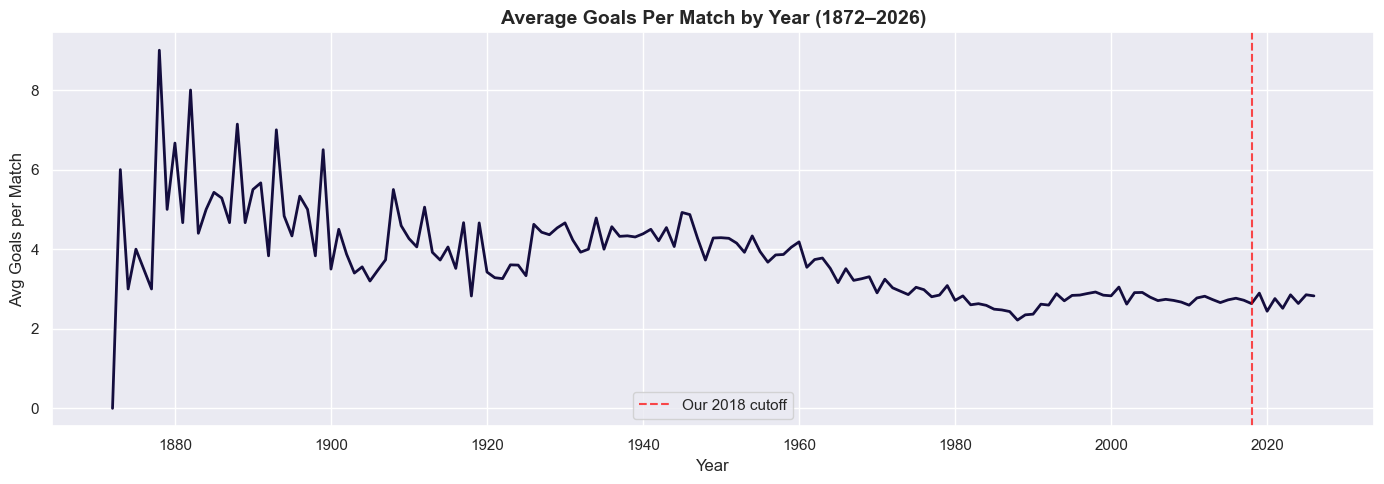

In [83]:
sns.set_theme(style='darkgrid')

df['year'] = df['date'].dt.year
goals_by_decade = df.copy()
goals_by_decade['total_goals'] = df['home_score'] + df['away_score']
goals_per_year = goals_by_decade.groupby('year')['total_goals'].mean()

plt.figure(figsize=(14, 5))
sns.lineplot(x=goals_per_year.index, y=goals_per_year.values, color='#140d3e', linewidth=2)
plt.title('Average Goals Per Match by Year (1872–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Avg Goals per Match')
plt.axvline(x=2018, color='red', linestyle='--', alpha=0.7, label='Our 2018 cutoff')
plt.legend()
plt.tight_layout()
plt.savefig('charts/goals_per_year.png', dpi=150)
plt.show()

Win/Draw/Loss split in competitive matches since 2018:
home_result
draw    22.0
loss    32.1
win     45.9
dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_10760\436105907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rates.index, y=win_rates.values, palette=['#1db954', '#555555', '#e63946'])


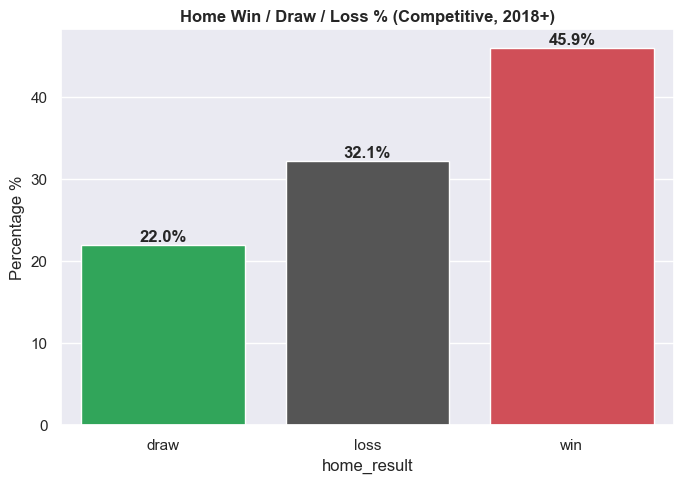

In [84]:
win_rates = df_competitive.groupby('home_result').size() / len(df_competitive) * 100
print("Win/Draw/Loss split in competitive matches since 2018:")
print(win_rates.round(1))

plt.figure(figsize=(7, 5))
sns.barplot(x=win_rates.index, y=win_rates.values, palette=['#1db954', '#555555', '#e63946'])
plt.title('Home Win / Draw / Loss % (Competitive, 2018+)', fontweight='bold')
plt.ylabel('Percentage %')
for i, val in enumerate(win_rates.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/home_win_rate.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10760\1751171892.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='goals_per_game', y='team', data=goals_df.head(15), palette='Greens_r')


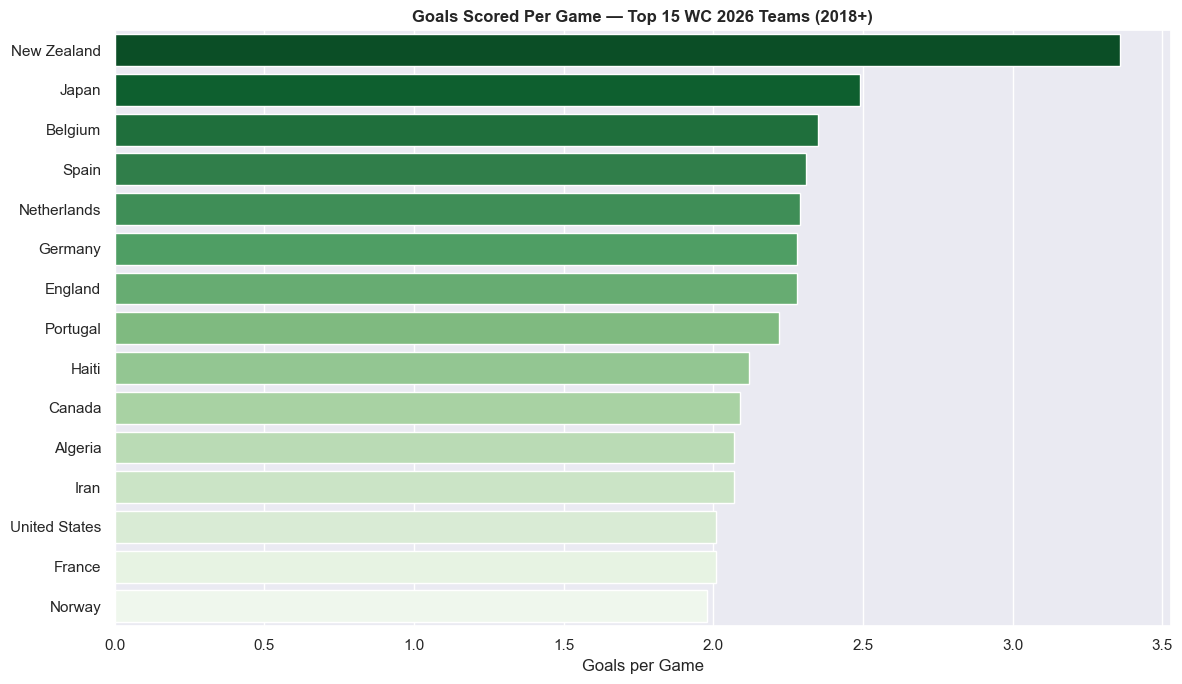

In [85]:
goals_scored = []
for team in wc_2026_teams:
    home_goals = df_competitive[df_competitive['home_team'] == team]['home_score'].sum()
    away_goals = df_competitive[df_competitive['away_team'] == team]['away_score'].sum()
    total_matches = len(df_competitive[
        (df_competitive['home_team'] == team) |
        (df_competitive['away_team'] == team)
    ])
    if total_matches > 0:
        goals_scored.append({
            'team': team,
            'goals_per_game': round((home_goals + away_goals) / total_matches, 2)
        })

goals_df = pd.DataFrame(goals_scored).sort_values('goals_per_game', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='goals_per_game', y='team', data=goals_df.head(15), palette='Greens_r')
plt.title('Goals Scored Per Game — Top 15 WC 2026 Teams (2018+)', fontweight='bold')
plt.xlabel('Goals per Game')
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/goals_per_game.png', dpi=150)
plt.show()

## Feature Engineering

In [86]:
# FIFA Rankings — June 2026 
fifa_rankings = {
    'Argentina':              1,
    'France':                 3,
    'Spain':                  2,
    'England':                4,
    'Brazil':                 6,
    'Portugal':               5,
    'Netherlands':            8,
    'Belgium':                9,
    'Germany':                10,
    'Uruguay':               10,
    'Colombia':              13,
    'Morocco':               7,
    'Japan':                 13,
    'Croatia':               11,
    'United States':         15,
    'Mexico':                14,
    'Senegal':               15,
    'Switzerland':           19,
    'Iran':                  20,
    'South Korea':           25,
    'Denmark':               21,
    'Austria':               23,
    'Turkey':                22,
    'Ecuador':               24,
    'Australia':             27,
    'Norway':                31,
    'Egypt':                 29,
    'Algeria':               28,
    'Canada':                30,
    'Tunisia':               46,
    'Sweden':                38,
    'Paraguay':              41,
    'Scotland':              43,
    'Ivory Coast':           33,
    'Czech Republic':        39,
    'South Africa':          60,
    'DR Congo':              45,
    'Ghana':                 73,
    'Qatar':                 55,
    'Saudi Arabia':          61,
    'Panama':                34,
    'Iraq':                  56,
    'Jordan':                63,
    'Cape Verde':            68,
    'New Zealand':           85,
    'Uzbekistan':            50,
    'Bosnia and Herzegovina':64,
    'Curaçao':               83,
    'Haiti':                 81,
}

In [87]:
def team_features(team_name, df, fifa_rankings, n_matches=40):
    home = df[df['home_team'] == team_name].copy()
    away = df[df['away_team'] == team_name].copy()

    home['goals_for']     = home['home_score']
    home['goals_against'] = home['away_score']
    home['won']           = home['home_score'] > home['away_score']

    away['goals_for']     = away['away_score']
    away['goals_against'] = away['home_score']
    away['won']           = away['away_score'] > away['home_score']

    combined = pd.concat([home, away]).sort_values('date').tail(n_matches)

    total = len(combined)
    if total == 0:
        return None

    win_rate       = combined['won'].sum() / total
    goals_scored   = combined['goals_for'].sum() / total
    goals_conceded = combined['goals_against'].sum() / total
    goal_diff      = goals_scored - goals_conceded
    ranking        = fifa_rankings.get(team_name, 50)  # default 50 if missing

    return {
        'team':              team_name,
        'matches_used':      total,
        'win_rate':          round(win_rate, 3),
        'goals_scored_pg':   round(goals_scored, 3),
        'goals_conceded_pg': round(goals_conceded, 3),
        'goal_diff':         round(goal_diff, 3),
        'fifa_ranking':      ranking,
    }

In [88]:
features_list = [team_features(t, df_competitive, fifa_rankings) for t in wc_2026_teams]
features_df = pd.DataFrame([f for f in features_list if f is not None])

# Ranking score: invert ranking so rank 1 = highest score
# We scale it between 0 and 1 so it's on the same scale as win_rate
max_rank = features_df['fifa_ranking'].max()
features_df['ranking_score'] = round(1 - (features_df['fifa_ranking'] - 1) / max_rank, 3)

features_df = features_df.sort_values('fifa_ranking').reset_index(drop=True)
print(features_df[['team', 'win_rate', 'goal_diff', 'ranking_score', 'matches_used']].to_string(index=False))

                  team  win_rate  goal_diff  ranking_score  matches_used
             Argentina     0.625      1.050          1.000            40
                 Spain     0.675      1.675          0.988            40
                France     0.625      1.350          0.976            40
               England     0.625      1.475          0.965            40
              Portugal     0.625      1.625          0.953            40
                Brazil     0.475      0.875          0.941            40
               Morocco     0.700      1.625          0.929            40
           Netherlands     0.500      1.125          0.918            40
               Belgium     0.450      1.000          0.906            40
               Uruguay     0.400      0.375          0.894            40
               Germany     0.550      1.600          0.894            40
               Croatia     0.475      0.825          0.882            40
                 Japan     0.675      1.950        

In [89]:
# New Zealand has only 22 matches — flag it so we know prediction is less reliable
nz = features_df[features_df['team'] == 'New Zealand']
print("New Zealand features:")
print(nz.to_string(index=False))
print(f"\nNote: only {nz['matches_used'].values[0]} matches used — lower confidence prediction")

New Zealand features:
       team  matches_used  win_rate  goals_scored_pg  goals_conceded_pg  goal_diff  fifa_ranking  ranking_score
New Zealand            14     0.714            3.357              0.214      3.143            85          0.012

Note: only 14 matches used — lower confidence prediction


In [90]:
features_df.to_csv('data/team_features.csv', index=False)
print("Saved: data/team_features.csv")

Saved: data/team_features.csv


### Visualising the Features

C:\Users\HP\AppData\Local\Temp\ipykernel_10760\713972794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate', y='team',


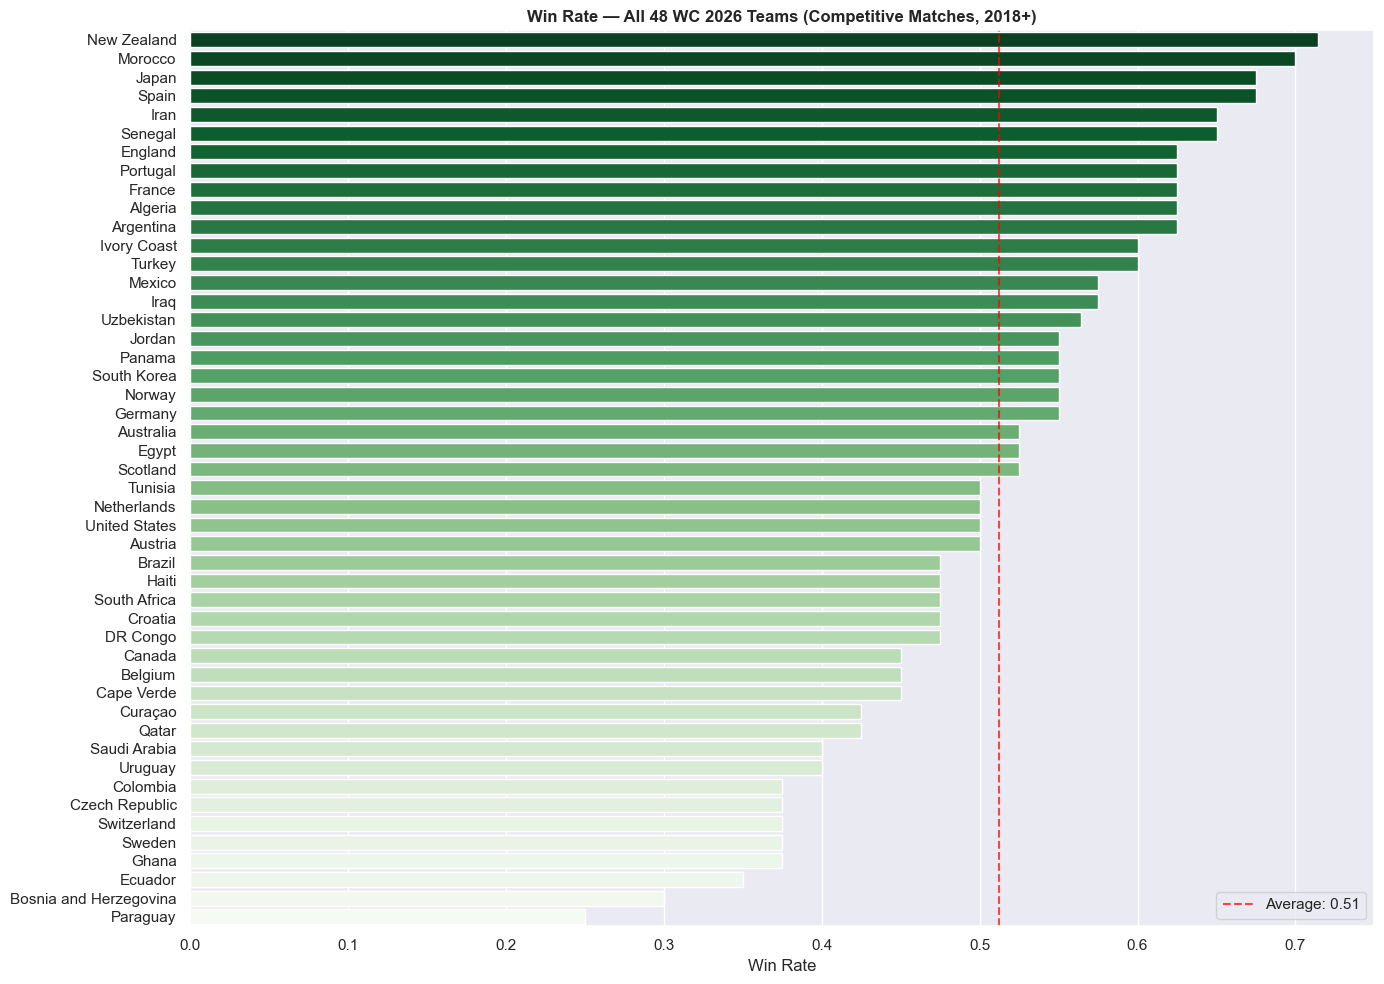

In [91]:
plt.figure(figsize=(14, 10))
sns.barplot(x='win_rate', y='team', 
            data=features_df.sort_values('win_rate', ascending=False), 
            palette='Greens_r')
plt.title('Win Rate — All 48 WC 2026 Teams (Competitive Matches, 2018+)', fontweight='bold')
plt.xlabel('Win Rate')
plt.ylabel('')
plt.axvline(x=features_df['win_rate'].mean(), color='red', linestyle='--',
            alpha=0.7, label=f"Average: {features_df['win_rate'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('charts/win_rates.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10760\2159230074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='goal_diff', y='team', data=goal_diff_sorted, palette=colors)


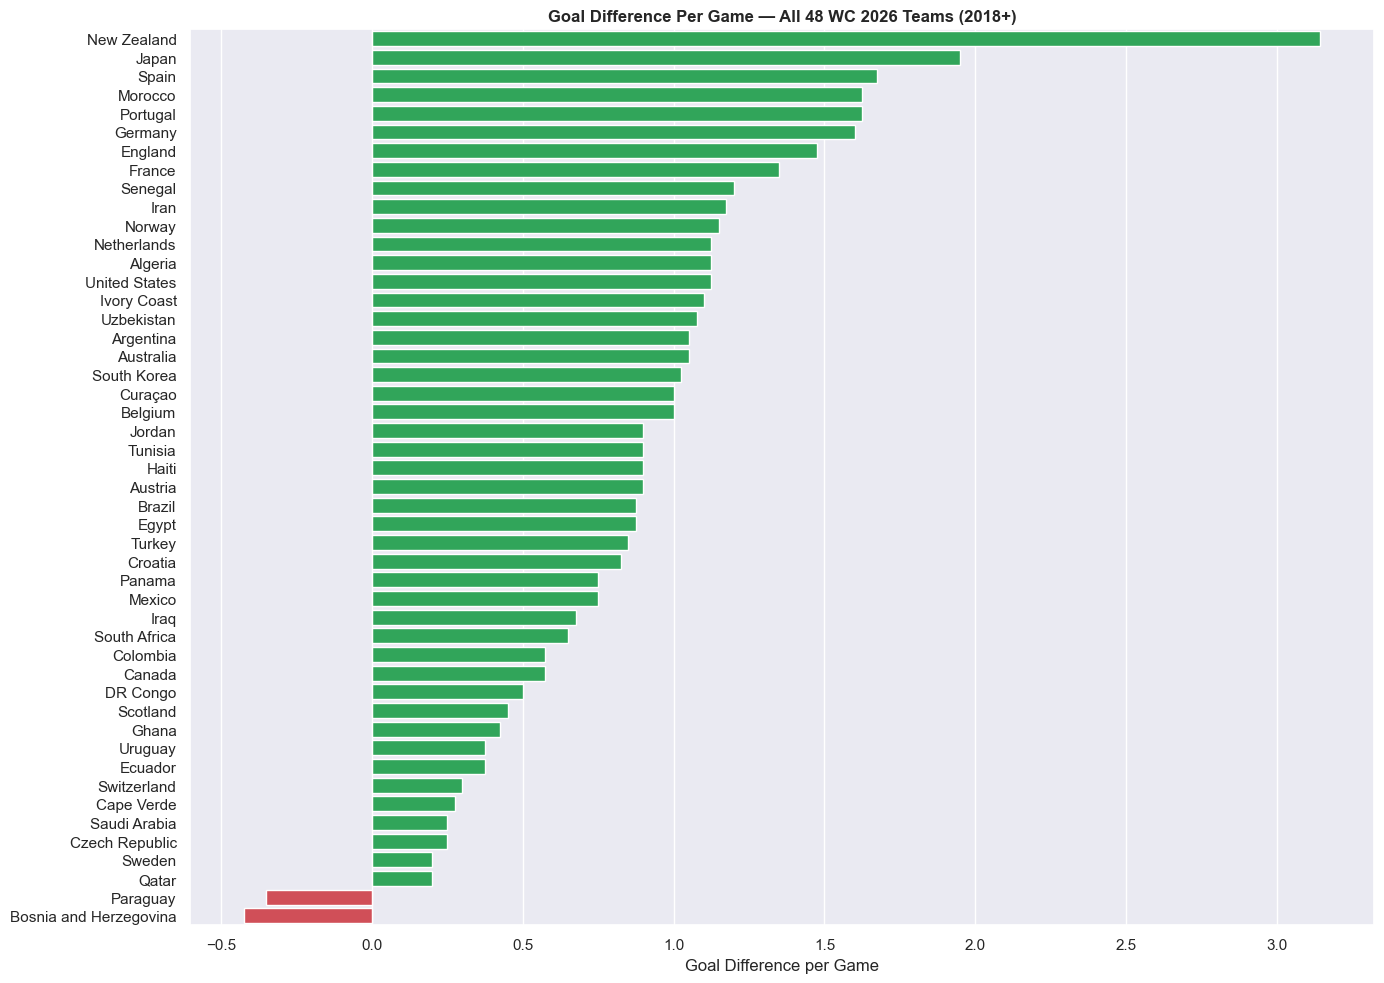

In [92]:
goal_diff_sorted = features_df.sort_values('goal_diff', ascending=False)

plt.figure(figsize=(14, 10))
colors = ['#1db954' if x > 0 else '#e63946' for x in goal_diff_sorted['goal_diff']]
sns.barplot(x='goal_diff', y='team', data=goal_diff_sorted, palette=colors)
plt.title('Goal Difference Per Game — All 48 WC 2026 Teams (2018+)', fontweight='bold')
plt.xlabel('Goal Difference per Game')
plt.ylabel('')
plt.axvline(x=0, color='white', linewidth=0.8)
plt.tight_layout()
plt.savefig('charts/goal_difference.png', dpi=150)
plt.show()

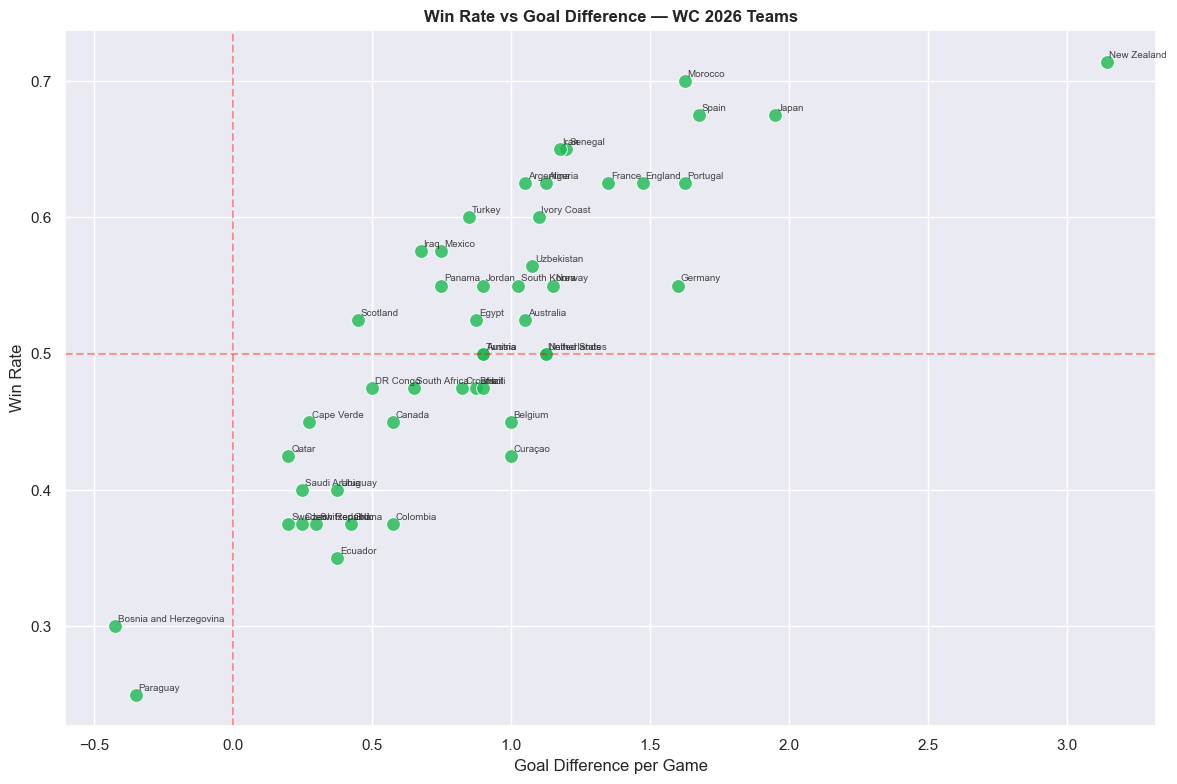

In [93]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=features_df,
    x='goal_diff',
    y='win_rate',
    s=100,
    color='#1db954',
    alpha=0.8
)

# Label every point with team name
for _, row in features_df.iterrows():
    plt.text(row['goal_diff'] + 0.01, row['win_rate'] + 0.003, 
             row['team'], fontsize=7, alpha=0.85)

plt.title('Win Rate vs Goal Difference — WC 2026 Teams', fontweight='bold')
plt.xlabel('Goal Difference per Game')
plt.ylabel('Win Rate')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.axvline(x=0,   color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/winrate_vs_goaldiff.png', dpi=150)
plt.show()

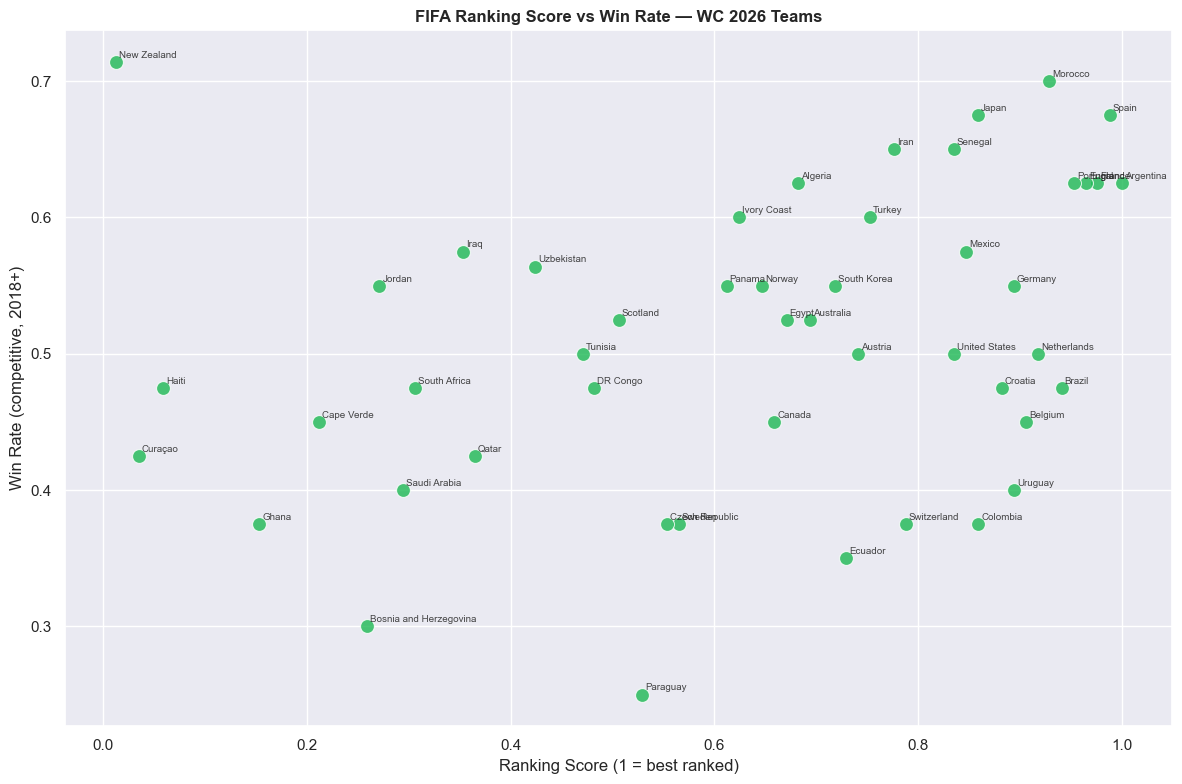

In [94]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=features_df,
    x='ranking_score',
    y='win_rate',
    s=100,
    color='#1db954',
    alpha=0.8
)

for _, row in features_df.iterrows():
    plt.text(row['ranking_score'] + 0.003, row['win_rate'] + 0.003,
             row['team'], fontsize=7, alpha=0.85)

plt.title('FIFA Ranking Score vs Win Rate — WC 2026 Teams', fontweight='bold')
plt.xlabel('Ranking Score (1 = best ranked)')
plt.ylabel('Win Rate (competitive, 2018+)')
plt.tight_layout()
plt.savefig('charts/ranking_vs_winrate.png', dpi=150)
plt.show()

In [95]:
print(features_df[['team', 'win_rate', 'goal_diff', 'matches_used']].to_string(index=False))

                  team  win_rate  goal_diff  matches_used
             Argentina     0.625      1.050            40
                 Spain     0.675      1.675            40
                France     0.625      1.350            40
               England     0.625      1.475            40
              Portugal     0.625      1.625            40
                Brazil     0.475      0.875            40
               Morocco     0.700      1.625            40
           Netherlands     0.500      1.125            40
               Belgium     0.450      1.000            40
               Uruguay     0.400      0.375            40
               Germany     0.550      1.600            40
               Croatia     0.475      0.825            40
                 Japan     0.675      1.950            40
              Colombia     0.375      0.575            40
                Mexico     0.575      0.750            40
               Senegal     0.650      1.200            40
         Unite